### Краткое описание проекта
* Quiz Freeze - игра, сборник вопросов в различных форматах и темах, на которые игрокам нужно давать ответы. 
* Игра одиночная, то есть каждый игрок отвечает на вопросы самостоятельно.
-------------------------------------------------------------------------------------------------------------------------------
**Этапы игры**
1. Регистрация -> registration / обязательный этап
2. Старт обучения -> tutorial_start /  опциональный этап
3. Завершение обучения -> tutorial_finish / может произойти только, если обучение было начато, можно не завершать обучение
4. Выбор уровня сложности вопросов -> level_choice / обязательное событие для перехода к следующему шагу/выбору пакета вопросов
5. Выбор пакетов вопросов -> pack_choice или  training_choice / выбор бесплатного набора вопросов
6. Покупка платных пакетов вопросов ->  факт совершения оплаты за платные вопросы
-------------------------------------------------------------------------------------------------------------------------------

### В ходе исследования буду проверены следующие гипотезы:
1. Отличается ли время прохождения различных этапов для пользователей, которые прошли обучение, от пользователей, не начинавших обучение. Насколько обучение сокращает время прохождения этапов?

2. Существует ли зависимость между вероятностью оплаты вопросов и количеством обучений, которые начинал или завершал пользователь. Нужно доказать, что успешное обучение само по себе влияет на оплату, и без разницы, каким этапом оно шло.

3. Дополнительная задача. Как часто пользователи начинают обучение после того, как они выбрали уровень сложности? Это позволит нам понять, насколько прозрачен процесс взаимодействия с игрой: если пользователи после выбора уровня сложности обращаются к обучению, значит, работа с приложением непонятна.

### Отличается ли время прохождения различных этапов для пользователей, которые прошли обучение, от пользователей, не начинавших обучение. Насколько обучение сокращает время прохождения этапов?

#### Загрузим и преобразуем данные. Создадим общий датафрейм.

In [31]:
pip install plotly

In [32]:
import pandas as pd

events_df = pd.read_csv('events.csv')
eventsf = events_df.loc[(events_df["start_time"] >= "2018-01-01T00:00:00") & (events_df["start_time"] <= "2018-31-12T00:00:00") & (events_df["event_type"] == 'registration')]
registered = eventsf.loc[eventsf["event_type"] == 'registration']["user_id"]

events = events_df[events_df.user_id.isin(registered)]
purchase_df = pd.read_csv('purchase.csv')
purchase = purchase_df[purchase_df.user_id.isin(registered)]
purchase.insert(4, "event_type", "purchase", True)
events = events.rename(columns={'id':'event_id'})
purchase = purchase.rename(columns={'id':'purchase_id'})


total_events_df = pd.concat([events,purchase],sort=False)
total_events_df = total_events_df.reset_index(drop=True).sort_values('start_time')
total_events_df.start_time = pd.to_datetime(total_events_df.start_time, format='%Y-%m-%dT%H:%M:%S')


purchase_df = total_events_df[total_events_df['event_type'] == 'purchase']
purchase_df = purchase_df[['user_id','event_datetime','amount']].rename(columns={'event_datetime':'purchase_time'})
purchase_df.purchase_time = pd.to_datetime(purchase_df.purchase_time, format='%Y-%m-%dT%H:%M:%S')
total_events_df.head()

,event_id,event_type,selected_level,start_time,tutorial_id,user_id,purchase_id,event_datetime,amount
0,80308.0,registration,NaN,2018-01-01 03:48:40,NaN,27832,NaN,NaN,NaN
1,80309.0,registration,NaN,2018-01-01 04:07:25,NaN,27833,NaN,NaN,NaN
2,80310.0,registration,NaN,2018-01-01 08:35:10,NaN,27834,NaN,NaN,NaN
3,80311.0,registration,NaN,2018-01-01 11:54:47,NaN,27835,NaN,NaN,NaN
4,80312.0,registration,NaN,2018-01-01 13:28:07,NaN,27836,NaN,NaN,NaN


#### Разделим пользователей на группы по признаку прохождения обучения.

10250 8068 19926 11858 1608
Отслеживаемые события в игре:
1 registration
2 tutorial_start
3 tutorial_finish
4 level_choice
5 pack_choice
6 purchase


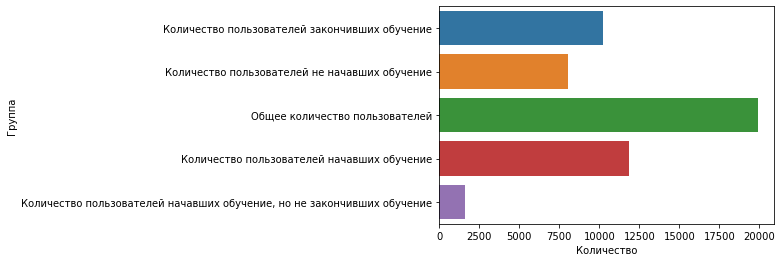

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

tutorial_start_df = total_events_df[total_events_df['event_type'] == 'tutorial_start'].sort_values('start_time').drop_duplicates('user_id')
tutorial_start_df.nunique()
tutorial_finish_df = total_events_df[total_events_df['event_type'] == 'tutorial_finish'].sort_values('start_time').drop_duplicates('user_id')


set_users_total = set(total_events_df["user_id"].unique())

users_wt = tutorial_finish_df["user_id"]
users_wst = tutorial_start_df["user_id"]

set_users_wst = set(users_wst) # те, кто хотя бы начинал обучение
set_users_wt = set(users_wt) # те,кто начал и закончил обучение
set_users_woft = set(users_wst).difference(set_users_wt) # те, кто начал, но не закончил обучение
set_users_wost = set_users_total.difference(set_users_wst) # те, кто вообще не начинал обучение


groups =['Количество пользователей закончивших обучение', 'Количество пользователей не начавших обучение', 'Общее количество пользователей', 'Количество пользователей начавших обучение', 'Количество пользователей начавших обучение, но не закончивших обучение']
data = {'Количество': [len(set_users_wt), len(set_users_wost), len(set_users_total), len(set_users_wst), len(set_users_woft)], 'Группа': groups}


len_df = pd.DataFrame(data)


print(len(set_users_wt), len(set_users_wost), len(set_users_total), len(set_users_wst), len(set_users_woft))
print('Отслеживаемые события в игре:')
for event in total_events_df.event_type.unique():
    print(total_events_df.event_type.unique().tolist().index(event) + 1, event)


    
g = sns.barplot(y = len_df['Группа'], x = len_df['Количество'], data=len_df)


## 1. Проверим отличается ли время прохождения различных этапов для пользователей, которые прошли обучение, от пользователей, не начинавших обучение

#### Создадим датафреймы с событиями для каждой группы пользователей

In [34]:
wt_events_df = total_events_df[total_events_df["user_id"].isin(set_users_wt)] # with full training
wst_events_df = total_events_df[total_events_df["user_id"].isin(set_users_wst)] # with started training (finished or unfinished)
wost_events_df = total_events_df[total_events_df["user_id"].isin(set_users_wost)] # without started training
woft_events_df = total_events_df[total_events_df["user_id"].isin(set_users_woft)] # with started but unfinished training

wt_events_df.head()

,event_id,event_type,selected_level,start_time,tutorial_id,user_id,purchase_id,event_datetime,amount
1,80309.0,registration,NaN,2018-01-01 04:07:25,NaN,27833,NaN,NaN,NaN
2,80310.0,registration,NaN,2018-01-01 08:35:10,NaN,27834,NaN,NaN,NaN
3,80311.0,registration,NaN,2018-01-01 11:54:47,NaN,27835,NaN,NaN,NaN
4,80312.0,registration,NaN,2018-01-01 13:28:07,NaN,27836,NaN,NaN,NaN
7,80315.0,tutorial_start,NaN,2018-01-01 14:54:40,31505.0,27836,NaN,NaN,NaN


#### Далее исследуем 3 группы пользователей:
1. С пройденным обучением
2. С начатым, но незаконченным обучением
3. Вообще без обучения

#### Для исследования разницы во времени при прохождении этапов в этих группах возьмем следующие события:
1. Регистрация - registration
2. Выбор уровня сложности - level_choice
3. Покупка - purchase

#### Это будет оптимальным вариантом поскольку события начала и конца обучения есть не во всех группах и у нас не получится сравнить по ним, а событие 'pack choice' - 'выбор набора вопросов' следует практически сразу после 'level choice' - 'выбор уровня сложности' и для уменьшения информационного шума имеет смысл рассматривать только одно из этих событий.
#### Таким образом разделим игру на два этапа:
1. До выбора уровня сложности бесплатного набора вопросов (может включать или не включать обучение).
2. От выбора уровня сложности до принятия решения о первой покупке.
#### Посмотрим как отличается время прохождения этих этапов в наших трех группах.

### Группа пользователей с пройденным обучением

#### В этой группе рассчитаем как время между выбранными нами этапами так и между всеми остальными псоледовательными этапами.
#### На примере этой группы покажем, что действительно временные промежутки между этапами, которые мы отбросили, незначительны и не могут повлиять на наши решения.

#### Время между началом обучения и выбором уровня сложности

In [35]:
# wt - with full training, ts - tutorial start, lc - level choice
# with training tutorial start - level_choice
wt_ts_df = wt_events_df[wt_events_df["event_type"] == "tutorial_start"].rename(columns={'start_time':'tutorial_start_time'}).sort_values('tutorial_start_time').drop_duplicates('user_id')
wt_lc_df = wt_events_df[wt_events_df["event_type"] == "level_choice"].rename(columns={'start_time':'level_choice_time'})
merged_ts_lc_wt = wt_ts_df.merge(wt_lc_df,on='user_id',how='inner')
merged_ts_lc_wt['timedelta'] = merged_ts_lc_wt['level_choice_time'] - merged_ts_lc_wt['tutorial_start_time']
merged_ts_lc_wt['timedelta'].describe()

count                         7501
mean     0 days 02:32:29.271030529
std      0 days 01:46:09.976258626
min                0 days 00:02:25
25%                0 days 01:15:50
50%                0 days 02:22:12
75%                0 days 03:33:37
max                0 days 21:29:36
Name: timedelta, dtype: object

#### Время между регистрацией и выбором уровня сложности

In [36]:
# with training registartion - level_choice
wt_reg_df = wt_events_df[wt_events_df["event_type"] == "registration"].rename(columns={'start_time':'registration_time'}).sort_values('registration_time').drop_duplicates('user_id')
merged_reg_lc_wt = wt_reg_df.merge(wt_lc_df,on='user_id',how='inner')
merged_reg_lc_wt['timedelta'] = merged_reg_lc_wt['level_choice_time'] - merged_reg_lc_wt['registration_time']
merged_reg_lc_wt['timedelta'].describe()

count                         7501
mean     0 days 07:05:36.854819357
std      0 days 04:30:23.231509186
min                0 days 00:08:15
25%                0 days 03:51:41
50%                0 days 06:00:07
75%                0 days 09:25:42
max                1 days 18:48:25
Name: timedelta, dtype: object

#### Время между регистрацией и началом обучения

In [37]:
# with training registartion - training start
merged_reg_ts_wt = wt_reg_df.merge(wt_ts_df,on='user_id',how='inner')
merged_reg_ts_wt['timedelta'] = merged_reg_ts_wt['tutorial_start_time'] - merged_reg_ts_wt['registration_time']
merged_reg_ts_wt['timedelta'].describe()

count                        10250
mean     0 days 04:31:04.938146341
std      0 days 04:11:24.828137380
min                0 days 00:00:34
25%         0 days 01:17:55.500000
50%                0 days 03:13:48
75%         0 days 06:37:27.750000
max                1 days 16:03:46
Name: timedelta, dtype: object

#### Время между концом обучения и выбором уровня сложности

In [38]:
# with training training finish - level_choice
wt_tf_df = wt_events_df[wt_events_df["event_type"] == "tutorial_finish"].rename(columns={'start_time':'tutorial_finish_time'}).sort_values('tutorial_finish_time').drop_duplicates('user_id')
merged_tf_lc_wt = wt_tf_df.merge(wt_lc_df,on='user_id',how='inner')
merged_tf_lc_wt['timedelta'] = merged_tf_lc_wt['level_choice_time'] - merged_tf_lc_wt['tutorial_finish_time']
merged_tf_lc_wt['timedelta'].describe()

count                         7501
mean     0 days 02:19:46.959472070
std      0 days 01:25:02.559683474
min                0 days 00:00:58
25%                0 days 01:09:02
50%                0 days 02:14:22
75%                0 days 03:24:32
max                0 days 06:36:45
Name: timedelta, dtype: object

#### Время между началом обучения и концом обучения

In [39]:
# with training training start - training finish
merged_ts_tf_wt = wt_ts_df.merge(wt_tf_df,on='user_id',how='inner')
merged_ts_tf_wt['timedelta'] = merged_ts_tf_wt['tutorial_finish_time'] - merged_ts_tf_wt['tutorial_start_time']
merged_ts_tf_wt['timedelta'].describe()

count                        10250
mean     0 days 00:12:13.823121951
std      0 days 01:01:28.012188068
min                0 days 00:00:16
25%                0 days 00:02:31
50%                0 days 00:03:49
75%                0 days 00:05:19
max                0 days 18:54:29
Name: timedelta, dtype: object

#### Время между выбором уровня сложности и выбром набора вопросов

In [40]:
# with training level_choice - pack_choice
wt_pc_df = wt_events_df[wt_events_df["event_type"] == "pack_choice"].rename(columns={'start_time':'pack_choice_time'}).sort_values('pack_choice_time').drop_duplicates('user_id')
merged_lc_pc_wt = wt_lc_df.merge(wt_pc_df,on='user_id',how='inner')
merged_lc_pc_wt['timedelta'] = merged_lc_pc_wt['pack_choice_time'] - merged_lc_pc_wt['level_choice_time']
print(merged_lc_pc_wt['timedelta'].describe())

count                         5176
mean     0 days 00:05:18.146058732
std      0 days 00:02:44.449118501
min                0 days 00:00:19
25%                0 days 00:03:05
50%                0 days 00:04:58
75%                0 days 00:07:11
max                0 days 00:15:48
Name: timedelta, dtype: object


#### Время между выбором набора вопросв и покупкой

In [41]:
# with training pack_choice - purchase
wt_pur_df = purchase_df[purchase_df["user_id"].isin(set_users_wt)]
#wt_pur_df = wt_events_df[wt_events_df["event_type"] == "purchase"].rename(columns={'start_time':'purchase_time'}).sort_values('purchase_time').drop_duplicates('user_id')
merged_pc_pur_wt = wt_pc_df.merge(wt_pur_df,on='user_id',how='inner')
merged_pc_pur_wt['timedelta'] = merged_pc_pur_wt['purchase_time'] - merged_pc_pur_wt['pack_choice_time']
print(merged_pc_pur_wt['timedelta'].describe())

count                         1447
mean     3 days 17:17:59.641326883
std      2 days 04:31:59.804658578
min                0 days 00:44:50
25%         1 days 21:16:05.500000
50%                3 days 12:15:56
75%         5 days 08:53:44.500000
max               10 days 18:33:59
Name: timedelta, dtype: object


#### Время между выбором уровня сложности и покупкой

In [42]:
# with training level_choice - purchase
wt_pur_df = purchase_df[purchase_df["user_id"].isin(set_users_wt)]
#wt_pur_df = wt_events_df[wt_events_df["event_type"] == "purchase"].rename(columns={'start_time':'purchase_time'}).sort_values('purchase_time').drop_duplicates('user_id')
merged_lc_pur_wt = wt_lc_df.merge(wt_pur_df,on='user_id',how='inner')
merged_lc_pur_wt['timedelta'] = merged_pc_pur_wt['purchase_time'] - merged_lc_pur_wt['level_choice_time']
print(merged_lc_pur_wt['timedelta'].describe())

count                         1447
mean     3 days 17:23:24.954388389
std      2 days 04:31:53.976587735
min                0 days 00:49:20
25%                1 days 21:20:34
50%                3 days 12:21:14
75%         5 days 08:56:39.500000
max               10 days 18:35:09
Name: timedelta, dtype: object


#### Ниже выведем столбчатую диаграмму и нормированную столбчатую диаграмму отражающую время между всеми последовательными этапами, а также между выбранными нами для оценки этапами.

In [43]:
wt_means_full = {'Регистрация - Начало обучения': round(merged_reg_ts_wt['timedelta'].mean().to_numpy().astype('timedelta64[m]') / np.timedelta64(60, 'm'), 2),
            'Начало обучения - Конец обучения': round(merged_ts_tf_wt['timedelta'].mean().to_numpy().astype('timedelta64[m]') / np.timedelta64(60, 'm'), 2), 
           'Конец обучения - Выбор уровня' : round(merged_tf_lc_wt['timedelta'].mean().to_numpy().astype('timedelta64[m]') / np.timedelta64(60, 'm'), 2),
           'Выбор уровня сложности - Выбор набора вопросов': round(merged_lc_pc_wt['timedelta'].mean().to_numpy().astype('timedelta64[m]') / np.timedelta64(60, 'm'), 2),
           'Выбор набора вопросов - Покупка': round(merged_pc_pur_wt['timedelta'].mean().to_numpy().astype('timedelta64[m]') / np.timedelta64(60, 'm'), 2)}

wt_means = {'Регистрация - Выбор уровня сложности бесплатных вопросов': round(merged_reg_lc_wt['timedelta'].mean().to_numpy().astype('timedelta64[m]') / np.timedelta64(60, 'm'), 2),
           'Выбор уровня сложности бесплатных вопросов - Покупка': round(merged_lc_pur_wt['timedelta'].mean().to_numpy().astype('timedelta64[m]') / np.timedelta64(60, 'm'), 2)}
             

'''

plt.figure(figsize=(16,5))
plt.bar(range(len(wt_means)), list(wt_means.values()), align='center', width=0.9, color='rgbymc')

    
plt.xticks(range(len(wt_means)), list(wt_means.keys()))

plt.show()
'''
import plotly.graph_objects as go
fig = go.Figure(
    data=[go.Bar(y=list(wt_means_full.values()), x=list(wt_means_full.keys()))],
    layout_title_text="Среднее время прохождения этапов игры в группе пользователей, прошедших обучение"
)
fig.show()

import plotly.express as px


df = pd.DataFrame(wt_means_full, index=['Группа пользователей с пройденным обучением'])

fig = px.bar(df)
fig.show()
#########################################
fig = go.Figure(
    data=[go.Bar(y=list(wt_means.values()), x=list(wt_means.keys()))],
    layout_title_text="Среднее время прохождения этапов игры в группе пользователей, прошедших обучение"
)
fig.show()

df = pd.DataFrame(wt_means, index=['Группа пользователей с пройденным обучением'])

fig = px.bar(df)
fig.show()


#### Благодаря диаграмме можно еще раз убедиться, что время между этапами:
#### Начало обучения - Конец обучения
#### Конец обучения - Выбор уровня
#### Выбор уровня сложности - Выбор набора вопросов
#### незначительно и его можно не принимать во внимание.

### Группа пользователей не начинавших обучение

In [44]:
# wost - without started training, ts - tutorial start, lc - level choice
# without started training registration - level choice
wost_reg_df = wost_events_df[wost_events_df["event_type"] == "registration"].rename(columns={'start_time':'registration_time'}).sort_values('registration_time').drop_duplicates('user_id')
wost_lc_df = wost_events_df[wost_events_df["event_type"] == "level_choice"].rename(columns={'start_time':'level_choice_time'}).sort_values('level_choice_time').drop_duplicates('user_id')
merged_reg_lc_wost = wost_reg_df.merge(wost_lc_df,on='user_id',how='inner')
merged_reg_lc_wost['timedelta'] = merged_reg_lc_wost['level_choice_time'] - merged_reg_lc_wost['registration_time']
merged_reg_lc_wost['timedelta'].describe()

count                           98
mean     0 days 05:15:33.122448979
std      0 days 03:41:00.594664298
min                0 days 00:09:26
25%         0 days 02:15:28.500000
50%         0 days 04:56:05.500000
75%                0 days 08:24:01
max                0 days 18:34:21
Name: timedelta, dtype: object

In [45]:
# wost - without started training, lc - level choice, pc - pack choice
# without started training level choice - pack choice
wost_pc_df = wost_events_df[wost_events_df["event_type"] == "pack_choice"].rename(columns={'start_time':'pack_choice_time'}).sort_values('pack_choice_time').drop_duplicates('user_id')
merged_lc_pc_wost = wost_lc_df.merge(wost_pc_df,on='user_id',how='inner')
merged_lc_pc_wost['timedelta'] = merged_lc_pc_wost['pack_choice_time'] - merged_lc_pc_wost['level_choice_time']
merged_lc_pc_wost['timedelta'].describe()

count                           74
mean     0 days 00:05:23.824324324
std      0 days 00:03:01.230146431
min                0 days 00:00:48
25%         0 days 00:03:09.750000
50%         0 days 00:04:46.500000
75%         0 days 00:07:11.250000
max                0 days 00:13:32
Name: timedelta, dtype: object

In [46]:
# without started training pack choice - level choice
wost_pur_df = purchase_df[purchase_df["user_id"].isin(set_users_wost)]
#wost_pur_df = wt_events_df[wt_events_df["event_type"] == "purchase"].rename(columns={'start_time':'purchase_time'}).sort_values('purchase_time').drop_duplicates('user_id')
merged_pc_pur_wost = wost_pc_df.merge(wost_pur_df,on='user_id',how='inner')
merged_pc_pur_wost['timedelta'] = merged_pc_pur_wost['purchase_time'] - merged_pc_pur_wost['pack_choice_time']
print(merged_pc_pur_wost['timedelta'].describe())

count                           22
mean     4 days 04:49:33.590909090
std      2 days 04:58:40.602573417
min                0 days 09:35:48
25%                2 days 15:49:22
50%                4 days 04:38:42
75%         5 days 23:34:55.750000
max                7 days 11:56:49
Name: timedelta, dtype: object


In [47]:
# without started level choice - purchase

merged_lc_pur_wost = wost_lc_df.merge(wost_pur_df,on='user_id',how='inner')
merged_lc_pur_wost['timedelta'] = merged_lc_pur_wost['purchase_time'] - merged_lc_pur_wost['level_choice_time']
print(merged_lc_pur_wost['timedelta'].describe())


count                           22
mean     4 days 04:54:56.272727272
std      2 days 04:57:49.388477288
min                0 days 09:38:00
25%                2 days 15:55:38
50%                4 days 04:43:59
75%         5 days 23:38:54.500000
max                7 days 12:02:02
Name: timedelta, dtype: object


In [48]:
wost_means = {'Регистрация - Выбор уровня сложности бесплатных вопросов': round(merged_reg_lc_wost['timedelta'].mean().to_numpy().astype('timedelta64[m]') / np.timedelta64(60, 'm'), 2),
           'Выбор уровня сложности бесплатных вопросов - Покупка': round(merged_lc_pur_wost['timedelta'].mean().to_numpy().astype('timedelta64[m]') / np.timedelta64(60, 'm'), 2)}
 
df = pd.DataFrame(wost_means, index=['Группа пользователей не начинавших обучение'])

fig = px.bar(df)
fig.show()

### Группа пользователей начавших, но не закончивших обучение

In [49]:
# woft - without finished training, ts - tutorial start, lc - level choice
# without finished training tutorial start - level_choice
woft_ts_df = woft_events_df[woft_events_df["event_type"] == "tutorial_start"].rename(columns={'start_time':'tutorial_start_time'}).sort_values('tutorial_start_time').drop_duplicates('user_id')
woft_lc_df = woft_events_df[woft_events_df["event_type"] == "level_choice"].rename(columns={'start_time':'level_choice_time'}).sort_values('level_choice_time').drop_duplicates('user_id')
merged_ts_lc_woft = woft_ts_df.merge(woft_lc_df,on='user_id',how='inner')
merged_ts_lc_woft['timedelta'] = merged_ts_lc_woft['level_choice_time'] - merged_ts_lc_woft['tutorial_start_time']
merged_ts_lc_woft['timedelta'].describe()

count                          743
mean     0 days 02:47:28.088829071
std      0 days 01:42:58.752826263
min                0 days 00:02:05
25%                0 days 01:27:58
50%                0 days 02:42:43
75%         0 days 04:01:45.500000
max                0 days 07:08:18
Name: timedelta, dtype: object

In [50]:
# without finished training registartion - level_choice
woft_reg_df = woft_events_df[woft_events_df["event_type"] == "registration"].rename(columns={'start_time':'registration_time'}).sort_values('registration_time').drop_duplicates('user_id')
merged_reg_lc_woft = woft_reg_df.merge(woft_lc_df,on='user_id',how='inner')
merged_reg_lc_woft['timedelta'] = merged_reg_lc_woft['level_choice_time'] - merged_reg_lc_woft['registration_time']
merged_reg_lc_woft['timedelta'].describe()

count                          743
mean     0 days 08:12:57.551816958
std      0 days 05:02:57.898561963
min                0 days 00:16:32
25%                0 days 04:34:49
50%                0 days 07:17:39
75%         0 days 11:11:56.500000
max                1 days 07:02:41
Name: timedelta, dtype: object

In [51]:
# without finished training level_choice - pack choice
woft_pc_df = woft_events_df[woft_events_df["event_type"] == "pack_choice"].rename(columns={'start_time':'pack_choice_time'}).sort_values('pack_choice_time').drop_duplicates('user_id')
merged_lc_pc_woft = woft_lc_df.merge(woft_pc_df,on='user_id',how='inner')
merged_lc_pc_woft['timedelta'] = merged_lc_pc_woft['pack_choice_time'] - merged_lc_pc_woft['level_choice_time']
print(merged_lc_pc_woft['timedelta'].describe())

count                          487
mean     0 days 00:05:05.295687885
std      0 days 00:02:35.198952502
min                0 days 00:00:24
25%                0 days 00:03:04
50%                0 days 00:04:48
75%                0 days 00:06:37
max                0 days 00:15:39
Name: timedelta, dtype: object


In [52]:
# without finished level choice - purchase
woft_pur_df = purchase_df[purchase_df["user_id"].isin(set_users_woft)]
merged_lc_pur_woft = woft_lc_df.merge(woft_pur_df,on='user_id',how='inner')
merged_lc_pur_woft['timedelta'] = merged_lc_pur_woft['purchase_time'] - merged_lc_pur_woft['level_choice_time']
print(merged_lc_pur_woft['timedelta'].describe())

count                          131
mean     3 days 21:20:00.488549618
std      2 days 05:36:52.787171825
min                0 days 05:35:40
25%         1 days 22:39:00.500000
50%                3 days 19:22:57
75%                5 days 13:49:01
max                8 days 15:34:20
Name: timedelta, dtype: object


In [53]:
woft_means = {'Регистрация - Выбор уровня сложности бесплатных вопросов': round(merged_reg_lc_woft['timedelta'].mean().to_numpy().astype('timedelta64[m]') / np.timedelta64(60, 'm'), 2),
           'Выбор уровня сложности бесплатных вопросов - Покупка': round(merged_lc_pur_woft['timedelta'].mean().to_numpy().astype('timedelta64[m]') / np.timedelta64(60, 'm'), 2)}
 
df = pd.DataFrame(woft_means, index=['Группа пользователей начавших, но не закончивших обучение'])


fig = px.bar(df)
fig.show()
df

,Регистрация - Выбор уровня сложности бесплатных вопросов,Выбор уровня сложности бесплатных вопросов - Покупка
"Группа пользователей начавших, но не закончивших обучение",8.2,93.33


#### Построим сравнительную диаграмму для всех трех групп

In [54]:
all_means = {'Регистрация - Выбор уровня сложности бесплатных вопросов': [round(merged_reg_lc_wt['timedelta'].mean().to_numpy().astype('timedelta64[m]') / np.timedelta64(60, 'm'), 2), round(merged_reg_lc_wost['timedelta'].mean().to_numpy().astype('timedelta64[m]') / np.timedelta64(60, 'm'), 2), round(merged_reg_lc_woft['timedelta'].mean().to_numpy().astype('timedelta64[m]') / np.timedelta64(60, 'm'), 2)],
           'Выбор уровня сложности бесплатных вопросов - Покупка': [round(merged_lc_pur_wt['timedelta'].mean().to_numpy().astype('timedelta64[m]') / np.timedelta64(60, 'm'), 2), round(merged_lc_pur_wost['timedelta'].mean().to_numpy().astype('timedelta64[m]') / np.timedelta64(60, 'm'), 2), round(merged_lc_pur_woft['timedelta'].mean().to_numpy().astype('timedelta64[m]') / np.timedelta64(60, 'm'), 2)]}
             
df = pd.DataFrame(all_means, index=['Группа пользователей с пройденным обучением','Группа пользователей не начинавших обучение','Группа пользователей начавших, но не закончивших обучение'])


fig = px.bar(df)
fig.show()
df

,Регистрация - Выбор уровня сложности бесплатных вопросов,Выбор уровня сложности бесплатных вопросов - Покупка
Группа пользователей с пройденным обучением,7.08,89.38
Группа пользователей не начинавших обучение,5.25,100.90
"Группа пользователей начавших, но не закончивших обучение",8.20,93.33


#### ВЫВОД: По полученным данным делаем вывод, что пройденное обучение однозначно сокаращает время до совершения первой покупки. В группе пользователей не начинавших обучение время между регистрацией и выбором уровня сложности сокращено за счет отсутствия этапа обучения. А в общем, группа пользователей прошедших обучение дошла до покупки в среднем на 7 % быстрее остальных групп.

## 2. Проверим существует ли зависимость между вероятностью оплаты вопросов и количеством обучений, которые начинал или завершал пользователь

#### Сформируем датафрейм со списками пройденных этапов по каждому пользователю

In [55]:
#list with events in chronology by users
user_path_df = total_events_df.groupby(['user_id'])['event_type'].apply(list).reset_index()
print(user_path_df.head(10))

   user_id                                         event_type
0    27832                                     [registration]
1    27833    [registration, tutorial_start, tutorial_finish]
2    27834    [registration, tutorial_start, tutorial_finish]
3    27835  [registration, tutorial_start, tutorial_finish...
4    27836  [registration, tutorial_start, tutorial_start,...
5    27837                                     [registration]
6    27838                                     [registration]
7    27839  [registration, tutorial_start, tutorial_finish...
8    27840       [registration, tutorial_start, level_choice]
9    27841    [registration, tutorial_start, tutorial_finish]


#### Подсчитаем сколько раз пользователь проходил каждый из этапов и запишем в словарь

In [56]:
#dictionary with number of events by users
def count_events(events_list):
    events_dicti = {}
    for c in events_list:
        events_dicti[c] = events_list.count(c)
    return events_dicti
def tostr(events_list):
    for c in events_list:
        c = str(c)
    return(events_list)
total_events_df['event_type'].apply(str)
user_path_df = total_events_df.groupby(['user_id'])['event_type'].apply(list).reset_index()

user_path_df['event_dict'] = user_path_df['event_type'].apply(count_events)
user_path_df.head(10)

,user_id,event_type,event_dict
0,27832,[registration],{'registration': 1}
1,27833,"[registration, tutorial_start, tutorial_finish]","{'registration': 1, 'tutorial_start': 1, 'tuto..."
2,27834,"[registration, tutorial_start, tutorial_finish]","{'registration': 1, 'tutorial_start': 1, 'tuto..."
3,27835,"[registration, tutorial_start, tutorial_finish...","{'registration': 1, 'tutorial_start': 1, 'tuto..."
4,27836,"[registration, tutorial_start, tutorial_start,...","{'registration': 1, 'tutorial_start': 2, 'tuto..."
5,27837,[registration],{'registration': 1}
6,27838,[registration],{'registration': 1}
7,27839,"[registration, tutorial_start, tutorial_finish...","{'registration': 1, 'tutorial_start': 1, 'tuto..."
8,27840,"[registration, tutorial_start, level_choice]","{'registration': 1, 'tutorial_start': 1, 'leve..."
9,27841,"[registration, tutorial_start, tutorial_finish]","{'registration': 1, 'tutorial_start': 1, 'tuto..."


#### Подсчитаем количество начатых (event_ts) и законченных (event_tf) обучений, а также проверим совпадает ли это количество по каждому пользователю (ok/not_ok). Пользователи, которые вообще не начинали обучение также отмечаются как not_ok.

In [57]:
#find numbers of tutorial starts and tutorial finishes
#find metric (ok or not_ok) if numbers are equal or not

def ts(event_dicti):
    try:
        c = event_dicti['tutorial_start']
    except:
        c = 0
    return c

def tf(event_dicti):
    try:
        c = event_dicti['tutorial_finish']
    except:
        c = 0
    return c

def tf_ts(event_dicti):
    try:
        if (event_dicti['tutorial_start'] - event_dicti['tutorial_finish'] == 0):
            return 'ok'
        else:
            return 'not_ok'
    except:
        return 'not_ok'


user_path_df['event_ts'] = user_path_df['event_dict'].apply(ts)
user_path_df['event_tf'] = user_path_df['event_dict'].apply(tf)
user_path_df['event_tf_ts'] = user_path_df['event_dict'].apply(tf_ts)
users_ok = set(user_path_df[user_path_df['event_tf_ts'] == 'ok']['user_id'])
users_not_ok = set(user_path_df[user_path_df['event_tf_ts'] == 'not_ok']['user_id'])

user_path_df.head(10)

,user_id,event_type,event_dict,event_ts,event_tf,event_tf_ts
0,27832,[registration],{'registration': 1},0,0,not_ok
1,27833,"[registration, tutorial_start, tutorial_finish]","{'registration': 1, 'tutorial_start': 1, 'tuto...",1,1,ok
2,27834,"[registration, tutorial_start, tutorial_finish]","{'registration': 1, 'tutorial_start': 1, 'tuto...",1,1,ok
3,27835,"[registration, tutorial_start, tutorial_finish...","{'registration': 1, 'tutorial_start': 1, 'tuto...",1,1,ok
4,27836,"[registration, tutorial_start, tutorial_start,...","{'registration': 1, 'tutorial_start': 2, 'tuto...",2,1,not_ok
5,27837,[registration],{'registration': 1},0,0,not_ok
6,27838,[registration],{'registration': 1},0,0,not_ok
7,27839,"[registration, tutorial_start, tutorial_finish...","{'registration': 1, 'tutorial_start': 1, 'tuto...",1,1,ok
8,27840,"[registration, tutorial_start, level_choice]","{'registration': 1, 'tutorial_start': 1, 'leve...",1,0,not_ok
9,27841,"[registration, tutorial_start, tutorial_finish]","{'registration': 1, 'tutorial_start': 1, 'tuto...",1,1,ok


#### Подсчитаем процент пользователей, совершивших оплату от общего числа пользователей в группах с различным количеством пройденных обучений (все обучения закончены).
#### Построим диаграмму, отражающую процент оплат и пользователей с различным количеством пройденных обучений.

In [58]:
#find payment percentage for groups different number of tutorial starts

pd.set_option('mode.chained_assignment', None)
merge_purchase_df = user_path_df.merge(purchase_df,on='user_id',how='inner') # no warning

#user_events_amount_df = user_path_df.groupby(['user_id'])['event_type'].apply(list).reset_index()
user_ts_df = user_path_df[user_path_df['event_tf_ts'] == 'ok'].groupby(['event_ts'])['user_id'].nunique().sort_values(ascending=False) # no warning
frame = {'count' : user_ts_df}
user_ts_df = pd.DataFrame(frame) # no warning

#print(merge_purchase_df[(merge_purchase_df['user_id'].isin(users_ok)) & (merge_purchase_df['event_ts'] == (1))]['user_id'].nunique()/user_ts_df['count'].iloc[0])

user_ts_df['pay_percentage'] = user_path_df['event_dict'].apply(tf_ts) # no warning

for i in range(len(user_path_df[user_path_df['event_tf_ts'] == 'ok']['event_ts'].unique())):
    user_ts_df['pay_percentage'].iloc[i] =  merge_purchase_df[(merge_purchase_df['user_id'].isin(users_ok)) & (merge_purchase_df['event_ts'] == (i+1))]['user_id'].nunique()/user_ts_df['count'].iloc[i] # no warning


user_ts_df_mod = user_ts_df.reset_index()
user_ts_df_mod = user_ts_df_mod.sort_values(by='event_ts')
print(user_ts_df_mod.head(15))
print(user_ts_df_mod['pay_percentage'].mean())


fig = px.line(user_ts_df_mod, x = user_ts_df_mod['event_ts'], y = user_ts_df_mod['pay_percentage'], color=px.Constant("Процент оплат"))
fig.add_bar(x = user_ts_df_mod['event_ts'], y = user_ts_df_mod['pay_percentage'], name = 'Процент оплат')
fig.show()

   event_ts  count pay_percentage
0         1   7548       0.143482
1         2   1117       0.142346
2         3    219       0.114155
3         4     98       0.122449
4         5     33       0.242424
6         6     31      0.0967742
5         7     31       0.129032
8         8     16           0.25
7         9     22       0.136364
0.1530028718480354


#### ВЫВОД: Как можно видеть на диаграмме - наивысший процент оплат у пользователей прошедших одно обучение (14.3 %). Можно наблюдать у пользователей с 5 (24.2 %) и с 8 (25 %) пройденными обучениями, но эти "всплески" связаны со снижением репрезентативности выборки ввиду ее очень малого размера (33 и 16 пользователей). Таким образом, можно сделать вывод, что количество пройденных обучений не влияет на вероятность оплаты и достаточно хотя бы одного пройденного обучения.

#### Теперь посмотрим, что происходит у пользователей, которые не завершили хотя бы одно обучение. Здесь собраны и те кто вообще не прошли обучение (0 пройденных обучений), и те, кто по какой-то причине проходил обучение несколько раз, но хотя бы одно из них оставил незавершенным.

In [59]:
#find pay percentage in group with at least one unfinished tutorial
pd.set_option('mode.chained_assignment', None)
user_ts_not_df = user_path_df[user_path_df['event_tf_ts'] == 'not_ok'].groupby(['event_ts'])['user_id'].nunique().sort_values(ascending=False)
user_ts_not_df.head()
frame_not = {'count' : user_ts_not_df}
user_ts_not_df = pd.DataFrame(frame_not)

user_ts_not_df['pay_percentage'] = user_path_df['event_dict'].apply(tf_ts)

for i in range(len(user_path_df[user_path_df['event_tf_ts'] == 'not_ok']['event_ts'].unique())):
    user_ts_not_df['pay_percentage'].iloc[i] =  merge_purchase_df[(merge_purchase_df['user_id'].isin(users_not_ok)) & (merge_purchase_df['event_ts'] == (i+1))]['user_id'].nunique()/user_ts_not_df['count'].iloc[i]
user_ts_not_df.head(15)

user_ts_not_df_mod = user_ts_not_df.reset_index()
user_ts_not_df_mod = user_ts_not_df_mod.sort_values(by='event_ts')
print(user_ts_not_df_mod.head(15))
print(user_ts_not_df_mod['pay_percentage'].mean())


fig = px.line(user_ts_not_df_mod, x = user_ts_not_df_mod['event_ts'], y = user_ts_not_df_mod['pay_percentage'], color=px.Constant("Процент оплат"))
fig.add_bar(x = user_ts_not_df_mod['event_ts'], y = user_ts_not_df_mod['pay_percentage'], name = 'Процент оплат')
fig.show()

   event_ts  count pay_percentage
0         0   8068      0.0153694
1         1   1555      0.0379421
2         2    472      0.0550847
3         3    208      0.0865385
4         4    123      0.0650407
7         5     76       0.131579
6         6     85       0.105882
9         7     63              0
8         8     70       0.185714
5         9     91        0.10989
0.07930410362444573


#### ВЫВОД: На этой диаграмме можно увидеть, что вероятность оплаты возрастает ввиду того, что там могут быть пользователи как с пройденными, так и с незавершенными обучениями. Однако у пользователей вообще не проходивших обучение процент оплат составляет около 1.5 %, что почти в 10 раз ниже чем у пользователей с одним пройденным обучением (14.3 %). Это подтверждает нашу гипотезу о влиянии пройденного обучения на вероятность оплаты.

## 3. Проверим как часто пользователи начинают обучение после того, как они выбрали уровень сложности.

#### Для начала сформируем словарь с позициями этапов в обще списке пройденных этапов пользователя. Это позволит нам увидеть, где этап прохождения обучения возникает после этапа выбор вопросов.

In [60]:
def pos_ts(events):
    try:
        return [i for i, j in enumerate(events) if j == 'tutorial_start']
    except:
        return 0
def pos_lc(events):
    try:
        return [i for i, j in enumerate(events) if j == 'level_choice']
    except:
        return 0 
def pos_tf(events):
    try:
        return [i for i, j in enumerate(events) if j == 'tutorial_finish']
    except:
        return 0

def pos_dict(events):
    pos_dict = {}
    values = []
    for v in events:
        values.append([i for i,d in enumerate(events) if d == v]) 
    pos_dict = dict(zip(events, values))
    
    return pos_dict

    
        
user_path_df['ts_pos'] = user_path_df['event_type'].apply(pos_ts)
user_path_df['tf_pos'] = user_path_df['event_type'].apply(pos_tf)
user_path_df['lc_pos'] = user_path_df['event_type'].apply(pos_lc)


'''
user_ts_pos_df = user_path_df[user_path_df['event_tf_ts'] == 'ok'].groupby(['ts_pos'])['user_id'].nunique().sort_values(ascending=False)
frame_pos = {'count' : user_ts_pos_df}
user_ts_pos_df = pd.DataFrame(frame_pos)

user_ts_pos_df.head()
'''




user_path_df['pos_dict'] = user_path_df['event_type'].apply(pos_dict)

user_path_df['pos_dict'].head(20)
    

0                                 {'registration': [0]}
1     {'registration': [0], 'tutorial_start': [1], '...
2     {'registration': [0], 'tutorial_start': [1], '...
3     {'registration': [0], 'tutorial_start': [1], '...
4     {'registration': [0], 'tutorial_start': [1, 2]...
5                                 {'registration': [0]}
6                                 {'registration': [0]}
7     {'registration': [0], 'tutorial_start': [1], '...
8     {'registration': [0], 'tutorial_start': [1], '...
9     {'registration': [0], 'tutorial_start': [1], '...
10    {'registration': [0], 'tutorial_start': [1, 4,...
11    {'registration': [0], 'tutorial_start': [1], '...
12                                {'registration': [0]}
13    {'registration': [0], 'tutorial_start': [1, 5]...
14    {'registration': [0], 'tutorial_start': [1], '...
15    {'registration': [0], 'tutorial_start': [1], '...
16                                {'registration': [0]}
17    {'registration': [0], 'tutorial_start': [1

#### Теперь посчитаем количество пользователей, которые начинали обучение после этапа выбор уровня сложности.

In [61]:
def ts_lc(positions):
    try:
        for i in positions['tutorial_start']:
            c = 'Прошли обучение перед выбором уровня сложности'
            if i > positions['level_choice'][0]:
                c = 'Прошли обучение после выбора уровня сложности'
        return c
    except:
        return 'Не проходили обучение или не выбирали уровень сложности'
    
user_path_df['ts_lc'] = user_path_df['pos_dict'].apply(ts_lc)

users_by_ts_lc = user_path_df.groupby(['ts_lc'])['user_id'].nunique().sort_values(ascending=False) # no warning

users_by_ts_lc_df = users_by_ts_lc.to_frame().reset_index()


fig = px.pie(users_by_ts_lc_df, values='user_id', names='ts_lc', title='Распределение пользователей по группам на основе очередности прохождения этапов')
fig.show()

#### ВЫВОД: Глядя на эту диаграмму может показаться, что достаточно небольшая часть пользователей проходит обучение после выбора уровня сложности - всего около 7%. Однако, стоит внимательнее изучить данные по этой группе - они могут подсказать изменения, которые улучшат игровой опыт в целом, и в других группах, и таким образом, эффект станет мультипликативным и рост процента оплат составит более чем 7%.

## Выводы по трем задачам:
## 1. Группа пользователей с пройденным обучением показал в среднем на 7 % меньшее время прохождения этапов чем группа пользователей без обучения и группа пользователей с незавершенным обучением.
## 2. Хотя бы одно пройденное обучение увеличивает вероятность оплаты почти в 10 раз. Количество пройденных обучений не повышает вероятность оплаты.
## 3. Всего 7% пользователей проходит обучение после выбора уровня сложности.